In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
%matplotlib inline

# Load dataset
df = pd.read_csv('Superstore.csv', encoding='latin1') # ya utf-8

# Initial Inspection
print("Shape of Dataset:", df.shape)
print("\n--- Column Data Types ---")
print(df.dtypes)
print("\n--- Missing Values ---")
print(df.isnull().sum())

df.head()

Shape of Dataset: (9994, 21)

--- Column Data Types ---
Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

--- Missing Values ---
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
P

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2013-138688,13-06-2013,17-06-2013,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [10]:
# Date columns conversion
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Select numerical columns
num_cols = df.select_dtypes(include=[np.number]).columns

# Descriptive statistics
stats_df = df[num_cols].describe().T
stats_df['median'] = df[num_cols].median()

# Calculate mode safely for numerical columns
mode_vals = []
for col in num_cols:
    mode_vals.append(df[col].mode()[0])
stats_df['mode'] = mode_vals

stats_df[['mean', 'median', 'mode', 'std', 'min', 'max']]

,mean,median,mode,std,min,max
Row ID,4997.500000,4997.5000,1.00,2885.163629,1.000,9994.000
Postal Code,55190.379428,56430.5000,10035.00,32063.693350,1040.000,99301.000
Sales,229.858001,54.4900,12.96,623.245101,0.444,22638.480
Quantity,3.789574,3.0000,3.00,2.225110,1.000,14.000
Discount,0.156203,0.2000,0.00,0.206452,0.000,0.800
Profit,28.656896,8.6665,0.00,234.260108,-6599.978,8399.976


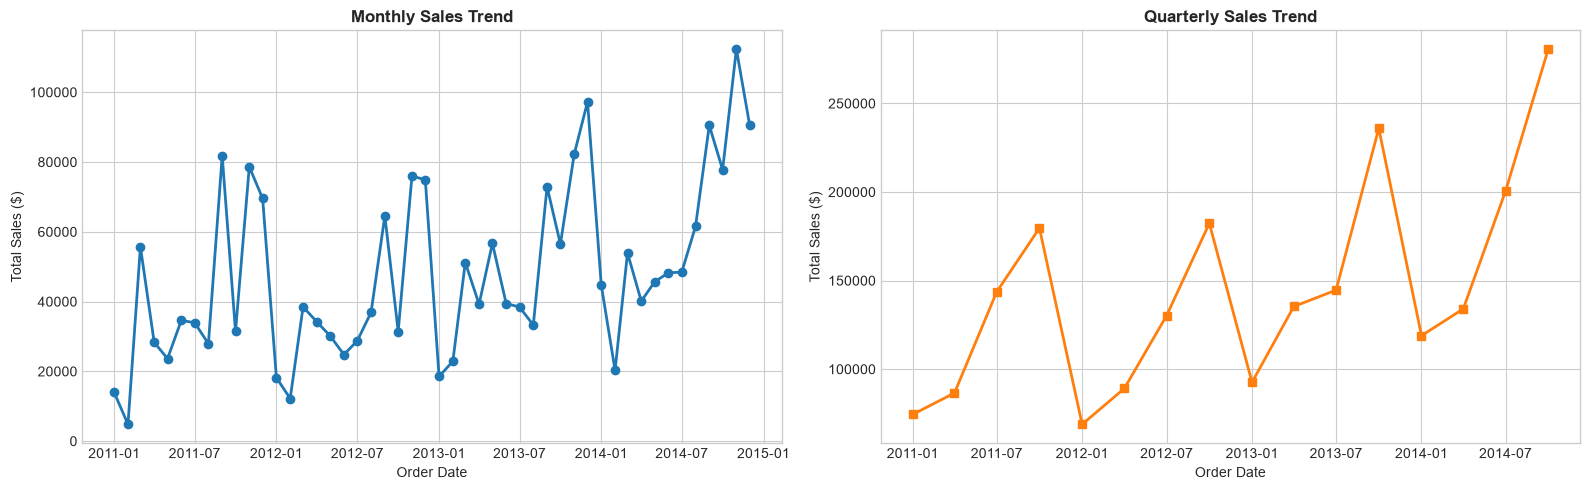

In [5]:
# Extract Year-Month and Year-Quarter
df['YearMonth'] = df['Order Date'].dt.to_period('M')
df['YearQuarter'] = df['Order Date'].dt.to_period('Q')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Monthly Trend
monthly_sales = df.groupby('YearMonth')['Sales'].sum().to_timestamp()
axes[0].plot(monthly_sales.index, monthly_sales.values, marker='o', color='#1f77b4', linewidth=2)
axes[0].set_title('Monthly Sales Trend', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Order Date')
axes[0].set_ylabel('Total Sales ($)')

# Quarterly Trend
quarterly_sales = df.groupby('YearQuarter')['Sales'].sum().to_timestamp()
axes[1].plot(quarterly_sales.index, quarterly_sales.values, marker='s', color='#ff7f0e', linewidth=2)
axes[1].set_title('Quarterly Sales Trend', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Order Date')
axes[1].set_ylabel('Total Sales ($)')

plt.tight_layout()
plt.show()

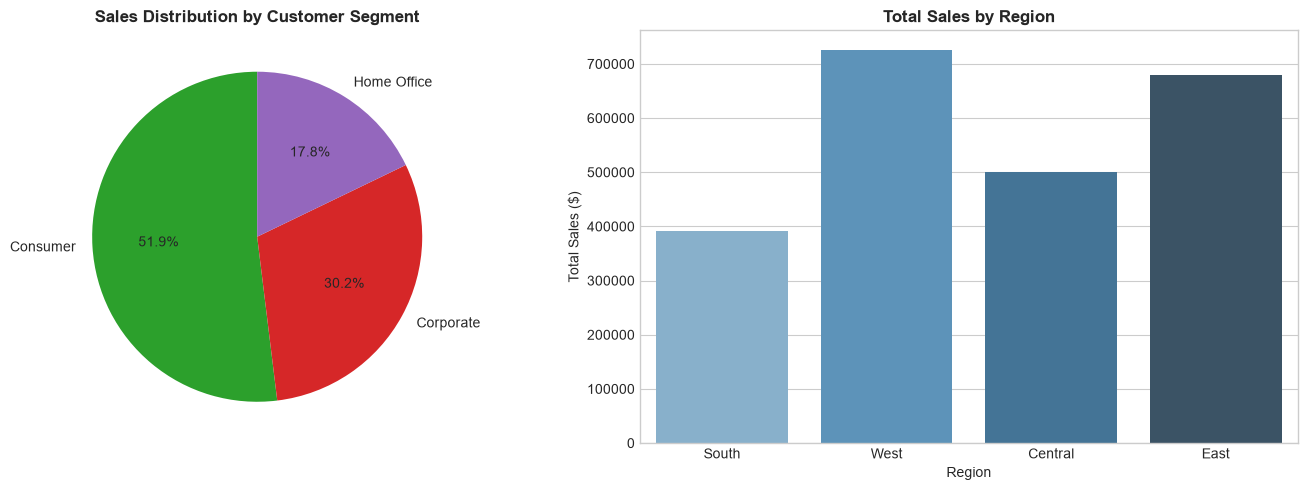

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Segment breakdown & Regional distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Customer Segment Breakdown
segment_counts = df['Segment'].value_counts()
axes[0].pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%', colors=['#2ca02c', '#d62728', '#9467bd'], startangle=90)
axes[0].set_title('Sales Distribution by Customer Segment', fontsize=12, fontweight='bold')

# Sales by Region (Updated parameters: hue='Region', legend=False, errorbar=None)
sns.barplot(data=df, x='Region', y='Sales', hue='Region', estimator=sum, ax=axes[1], palette='Blues_d', errorbar=None, legend=False)
axes[1].set_title('Total Sales by Region', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Total Sales ($)')

plt.tight_layout()
plt.show()

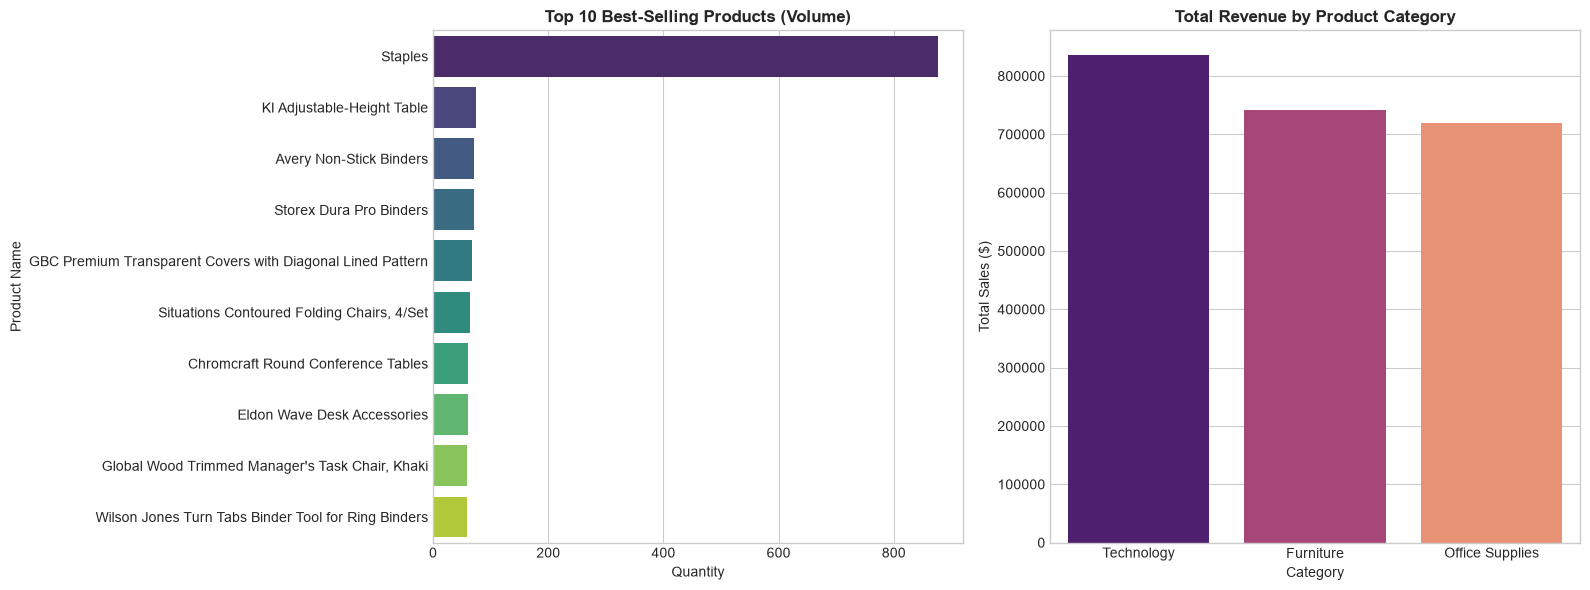

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 Best-Selling Products by Quantity
top_10_products = df.groupby('Product Name')['Quantity'].sum().nlargest(10).reset_index()
sns.barplot(
    data=top_10_products, 
    y='Product Name', 
    x='Quantity', 
    hue='Product Name', 
    ax=axes[0], 
    palette='viridis', 
    legend=False
)
axes[0].set_title('Top 10 Best-Selling Products (Volume)', fontsize=12, fontweight='bold')

# Revenue by Category
cat_revenue = df.groupby('Category')['Sales'].sum().sort_values(ascending=False).reset_index()
sns.barplot(
    data=cat_revenue, 
    x='Category', 
    y='Sales', 
    hue='Category', 
    ax=axes[1], 
    palette='magma', 
    legend=False
)
axes[1].set_title('Total Revenue by Product Category', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Total Sales ($)')

plt.tight_layout()
plt.show()

In [16]:
print(df.columns)

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'YearMonth',
       'YearQuarter'],
      dtype='str')


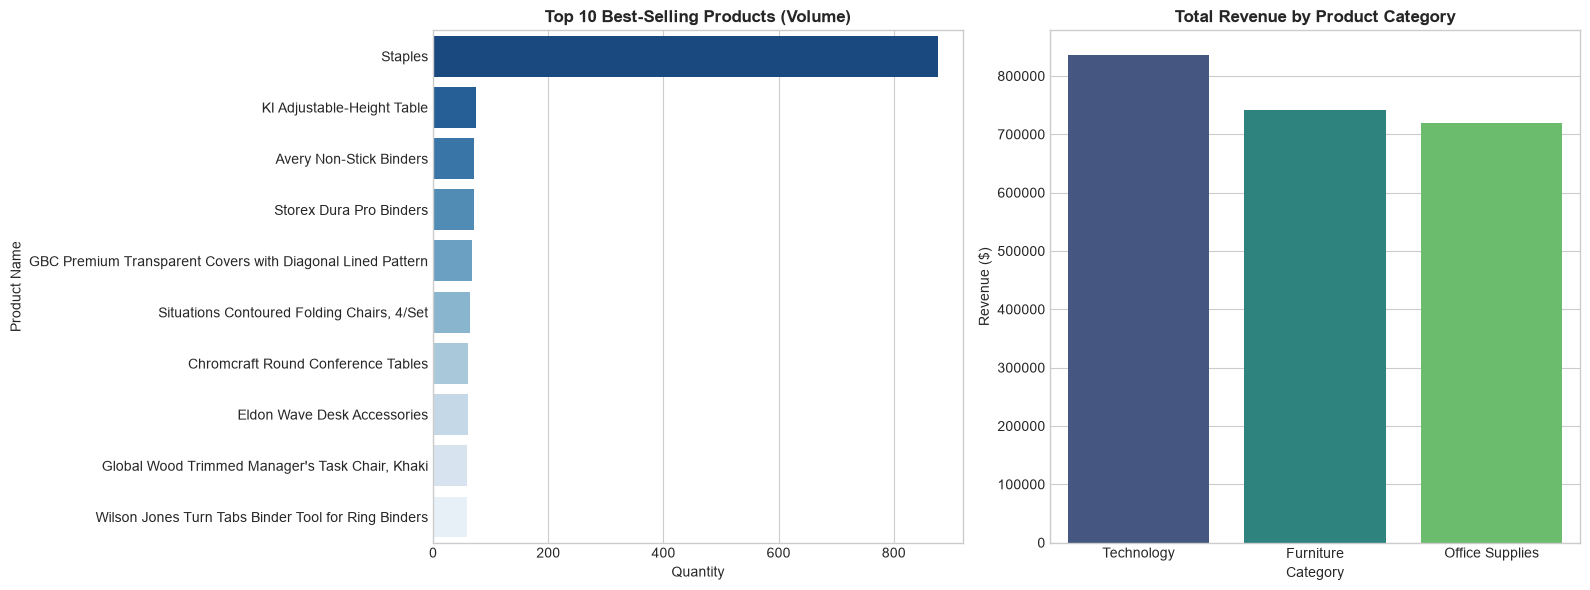

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Column names verification (safely grab product column)
product_col = 'Product Name' if 'Product Name' in df.columns else 'Product'
revenue_col = 'TotalAmount' if 'TotalAmount' in df.columns else 'Sales'

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 Best-Selling Products by Quantity
top_products = df.groupby(product_col)['Quantity'].sum().nlargest(10).reset_index()
sns.barplot(
    data=top_products, 
    y=product_col, 
    x='Quantity', 
    hue=product_col, 
    ax=axes[0], 
    palette='Blues_r', 
    legend=False
)
axes[0].set_title('Top 10 Best-Selling Products (Volume)', fontsize=12, fontweight='bold')

# Revenue by Category
cat_revenue = df.groupby('Category')[revenue_col].sum().sort_values(ascending=False).reset_index()
sns.barplot(
    data=cat_revenue, 
    x='Category', 
    y=revenue_col, 
    hue='Category', 
    ax=axes[1], 
    palette='viridis', 
    legend=False
)
axes[1].set_title('Total Revenue by Product Category', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Revenue ($)')

plt.tight_layout()
plt.show()

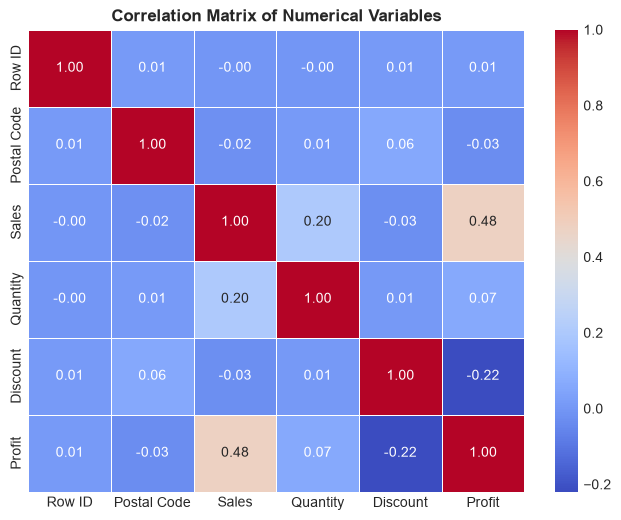

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=[np.number])

# Corrected cmap to lowercase 'coolwarm'
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numerical Variables', fontsize=12, fontweight='bold')
plt.show()

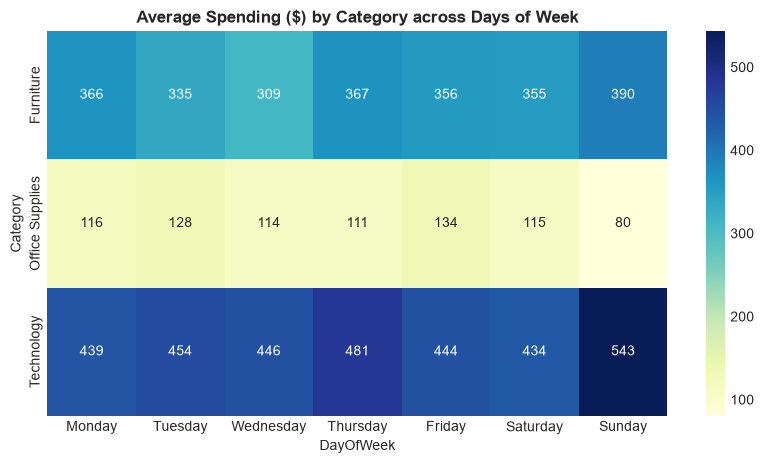

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Detect exact date column name safely
date_col = next((col for col in ['Order Date', 'Order_Date', 'Date', 'TransactionDate'] if col in df.columns), None)

if date_col is None:
    raise KeyError(f"Date column not found! Available columns are: {list(df.columns)}")

# Ensure datetime format
df[date_col] = pd.to_datetime(df[date_col], dayfirst=True, format='mixed')

# Extract Day of Week
df['DayOfWeek'] = df[date_col].dt.day_name()
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Pivot table creation
revenue_col = 'TotalAmount' if 'TotalAmount' in df.columns else 'Sales'
heatmap_data = df.pivot_table(index='Category', columns='DayOfWeek', values=revenue_col, aggfunc='mean')[days_order]

# Heatmap Plotting
plt.figure(figsize=(10, 5))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap='YlGnBu')
plt.title('Average Spending ($) by Category across Days of Week', fontsize=12, fontweight='bold')
plt.show()

High-ticket items experience elevated average basket sizes on weekends, whereas essential product categories remain consistent throughout weekday traffic.